In [59]:
import os
import json
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

In [60]:
#loading data
from pathlib import Path

DATA_ROOT = Path("C:\\Users\\Niraj Mhatre\\projects\\motor_insurance_data\\Data\\CarDD_release\\CarDD_release")

COCO_DIR = DATA_ROOT / "CarDD_COCO"

TRAIN_DIR = COCO_DIR / "train2017"
VAL_DIR = COCO_DIR / "val2017"
TEST_DIR = COCO_DIR / "test2017"

ANNOTATION_DIR = COCO_DIR / "annotations"

In [61]:
#verifying directory structure
print("COCO folder exists:", COCO_DIR.exists())
print("Train folder exists:", TRAIN_DIR.exists())
print("Validation folder exists:", VAL_DIR.exists())
print("Test folder exists:", TEST_DIR.exists())
print("Annotation folder exists:", ANNOTATION_DIR.exists())

COCO folder exists: True
Train folder exists: True
Validation folder exists: True
Test folder exists: True
Annotation folder exists: True


In [62]:
print("Contents of CarDD_COCO:")
for item in COCO_DIR.iterdir():
    print(item.name)

Contents of CarDD_COCO:
annotations
test2017
train2017
val2017


In [63]:
print("Files inside annotations folder:\n")
for item in ANNOTATION_DIR.iterdir():
    print(item.name)

Files inside annotations folder:

image_info.xlsx
instances_test2017.json
instances_train2017.json
instances_val2017.json


In [64]:
train_images = list(TRAIN_DIR.iterdir())
print("Number of training files:", len(train_images))

Number of training files: 2816


In [65]:
val_images = list(VAL_DIR.iterdir())
print("Number of validation files:", len(val_images))

Number of validation files: 810


In [66]:
test_images = list(TEST_DIR.iterdir())
print("Number of test files:", len(test_images))

Number of test files: 374


In [67]:
#first 10 training images
for file in train_images[:10]:
    print(file.name)

000001.jpg
000002.jpg
000003.jpg
000004.jpg
000005.jpg
000006.jpg
000007.jpg
000008.jpg
000009.jpg
000010.jpg


Image size: (1000, 750)
Image mode: RGB


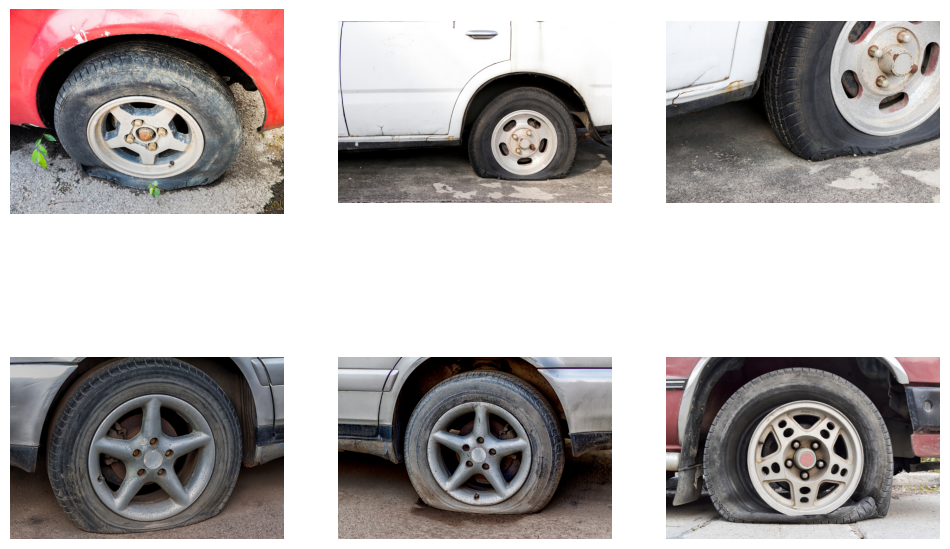

In [68]:
#checking dimension of 1st image and a few images
first_image = train_images[0]
img = Image.open(first_image)
print("Image size:", img.size)
print("Image mode:", img.mode)
plt.figure(figsize=(12, 8))

for i in range(6):
    img = Image.open(train_images[i])

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [69]:
json_files = list(ANNOTATION_DIR.glob("*.json"))
print("JSON files found:\n")
for file in json_files:
    print(file.name)

print("Number of JSON files:", len(json_files))

JSON files found:

instances_test2017.json
instances_train2017.json
instances_val2017.json
Number of JSON files: 3


In [70]:
annotation_file = ANNOTATION_DIR / "instances_train2017.json"

print(annotation_file)

C:\Users\Niraj Mhatre\projects\motor_insurance_data\Data\CarDD_release\CarDD_release\CarDD_COCO\annotations\instances_train2017.json


In [71]:
with open(annotation_file, "r") as file:
    data = json.load(file)

print(type(data))
print(data.keys())
print("Number of image records:", len(data["images"]))

<class 'dict'>
dict_keys(['licenses', 'info', 'categories', 'images', 'annotations'])
Number of image records: 2816


In [72]:
#data for 1st image
first_image_info = data["images"][0]

print("Image ID:", first_image_info["id"])
print("File name:", first_image_info["file_name"])
print("Width:", first_image_info["width"])
print("Height:", first_image_info["height"])

Image ID: 1
File name: 000001.jpg
Width: 1000
Height: 750


In [73]:
#looking at total number of annotations
print("Number of annotations:", len(data["annotations"]))

Number of annotations: 6211


In [74]:
data["annotations"][0]

{'id': 1,
 'image_id': 1,
 'category_id': 2,
 'segmentation': [[233.35,
   46.65,
   217.25,
   58.24,
   210.82,
   65.97,
   204.38,
   78.2,
   197.3,
   93.0,
   192.15,
   104.59,
   187.0,
   112.96,
   180.56,
   123.91,
   174.12,
   135.49,
   169.61,
   144.51,
   167.04,
   154.16,
   167.04,
   165.11,
   175.41,
   170.9,
   185.71,
   171.55,
   196.01,
   167.68,
   205.02,
   161.24,
   214.03,
   154.81,
   224.33,
   148.37,
   233.99,
   141.93,
   244.29,
   134.21,
   256.52,
   128.41,
   267.47,
   125.19,
   277.77,
   122.62,
   288.71,
   119.4,
   298.37,
   116.82,
   310.6,
   113.61,
   322.83,
   109.1,
   333.13,
   105.88,
   344.08,
   103.95,
   355.02,
   101.37,
   366.61,
   97.51,
   369.83,
   87.21,
   364.68,
   78.84,
   352.45,
   69.18,
   341.5,
   61.46,
   331.2,
   55.02,
   314.46,
   48.58,
   302.23,
   44.72,
   291.93,
   42.15,
   276.48,
   40.21,
   266.18,
   40.21,
   254.59,
   40.21]],
 'area': 13584.0,
 'bbox': [167.04, 40.2

In [75]:
#looking annotations for 1st image
first_annotation = data["annotations"][0]

print("Annotation ID:", first_annotation["id"])
print("Image ID:", first_annotation["image_id"])
print("Category ID:", first_annotation["category_id"])
print("Bounding box:", first_annotation["bbox"])

Annotation ID: 1
Image ID: 1
Category ID: 2
Bounding box: [167.04, 40.21, 202.79, 131.34]


In [76]:
#we will look at number of catrogories
print("Number of categories:", len(data["categories"]))
print(data["categories"])

Number of categories: 6
[{'id': 1, 'name': 'dent'}, {'id': 2, 'name': 'scratch'}, {'id': 3, 'name': 'crack'}, {'id': 4, 'name': 'glass shatter'}, {'id': 5, 'name': 'lamp broken'}, {'id': 6, 'name': 'tire flat'}]


In [77]:
#creating a cateogory dictonary for advanced even though it exists in another format in the data
category_dict = {}

for category in data["categories"]:
    category_dict[category["id"]] = category["name"]

print(category_dict)

{1: 'dent', 2: 'scratch', 3: 'crack', 4: 'glass shatter', 5: 'lamp broken', 6: 'tire flat'}


In [78]:
#checkinh if image ids and annotations connect
image_ids = set()

for image in data["images"]:
    image_ids.add(image["id"])

print("Number of unique image IDs:", len(image_ids))

Number of unique image IDs: 2816


In [79]:
annotation_image_ids = set()

for annotation in data["annotations"]:
    annotation_image_ids.add(annotation["image_id"])

print("Number of unique images having annotations:", len(annotation_image_ids))

Number of unique images having annotations: 2816


hence we see no missing annotations


In [80]:
#checking for duplkicate ids
all_image_ids = [image["id"] for image in data["images"]]
print("Total image records:", len(all_image_ids))
print("Unique image IDs:", len(set(all_image_ids)))
all_annotation_ids = [annotation["id"] for annotation in data["annotations"]]
print("Total annotation records:", len(all_annotation_ids))
print("Unique annotation IDs:", len(set(all_annotation_ids)))

Total image records: 2816
Unique image IDs: 2816
Total annotation records: 6211
Unique annotation IDs: 6211


In [81]:
from collections import Counter

category_counts = Counter()

for annotation in data["annotations"]:
    category_counts[annotation["category_id"]] += 1

for category_id, count in category_counts.items():
    print(category_dict[category_id], ":", count)

scratch : 2560
tire flat : 225
crack : 651
dent : 1806
lamp broken : 494
glass shatter : 475


In [82]:
print("========== CARDD DATA CHECK ==========")

print("\nFolders:")
print("Train:", TRAIN_DIR.exists())
print("Validation:", VAL_DIR.exists())
print("Test:", TEST_DIR.exists())
print("Annotations:", ANNOTATION_DIR.exists())

print("\nImages:")
train_count = len(train_images)
val_count = len(val_images)
test_count = len(test_images)

print("Train:", train_count)
print("Validation:", val_count)
print("Test:", test_count)

print("\nAnnotations:")
print("Image records:", len(data["images"]))
print("Annotation records:", len(data["annotations"]))
print("Categories:", len(data["categories"]))

print("\nCategory names:")
for category in data["categories"]:
    print("-", category["name"])

========== CARDD DATA CHECK ==========

Folders:
Train: True
Validation: True
Test: True
Annotations: True

Images:
Train: 2816
Validation: 810
Test: 374

Annotations:
Image records: 2816
Annotation records: 6211
Categories: 6

Category names:
- dent
- scratch
- crack
- glass shatter
- lamp broken
- tire flat


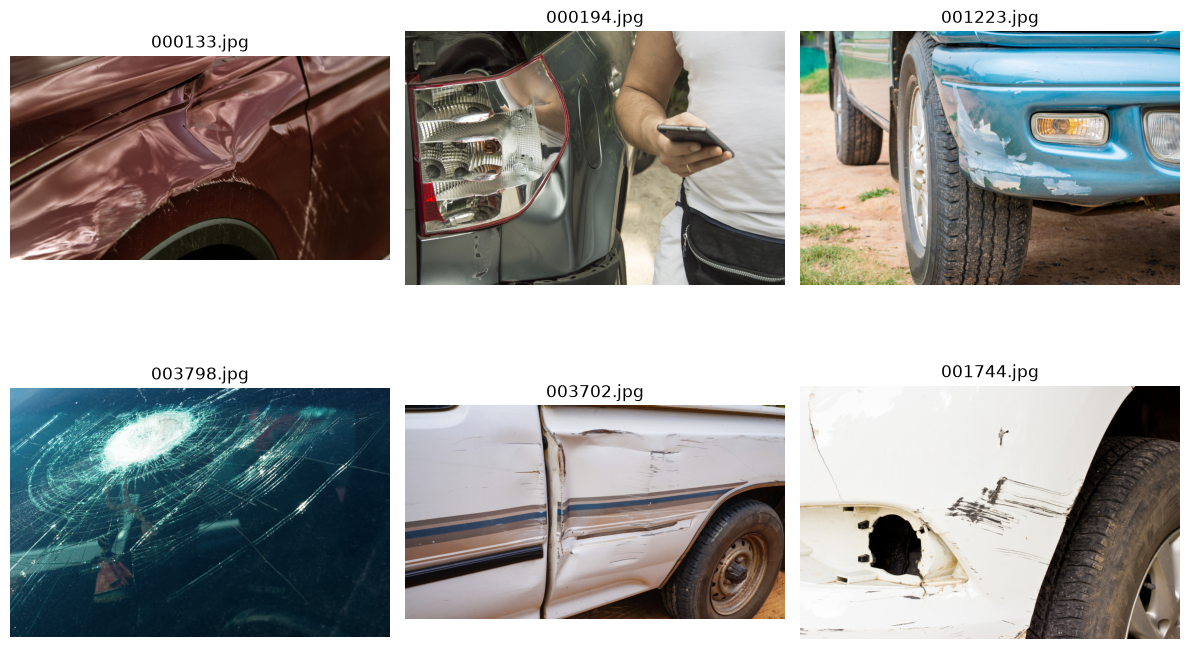

In [83]:
import random

random_images = random.sample(train_images, 6)

plt.figure(figsize=(12, 8))

for i, image_path in enumerate(random_images):
    img = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

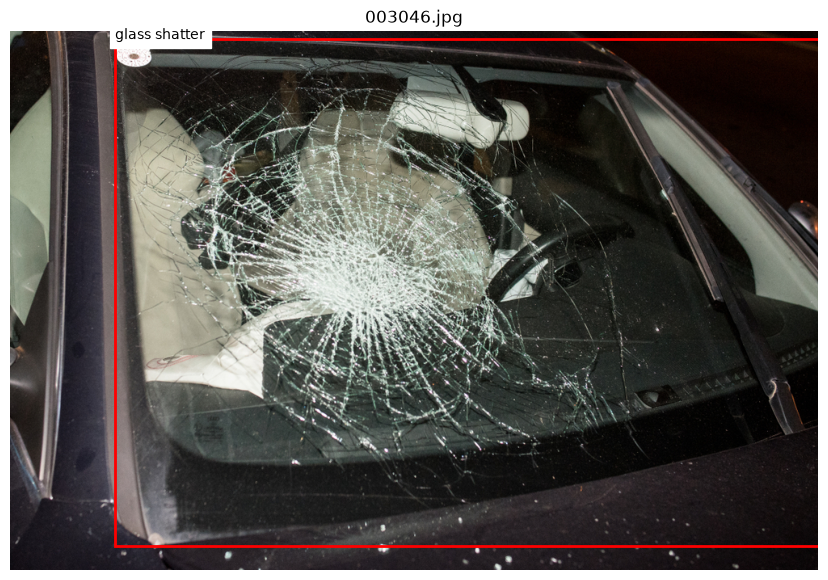

In [84]:
import matplotlib.patches as patches
image_info_dict = {}

for image in data["images"]:
    image_info_dict[image["file_name"]] = image

annotation_dict = {}

for annotation in data["annotations"]:
    image_id = annotation["image_id"]

    if image_id not in annotation_dict:
        annotation_dict[image_id] = []

    annotation_dict[image_id].append(annotation)    

image_path = random.choice(train_images)

img = Image.open(image_path)

image_name = image_path.name
image_info = image_info_dict[image_name]

image_id = image_info["id"]

plt.figure(figsize=(12, 7))
plt.imshow(img)

if image_id in annotation_dict:

    for annotation in annotation_dict[image_id]:

        x, y, width, height = annotation["bbox"]

        category_id = annotation["category_id"]
        category_name = category_dict[category_id]

        rectangle = patches.Rectangle(
            (x, y),
            width,
            height,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        plt.gca().add_patch(rectangle)

        plt.text(
            x,
            y,
            category_name,
            fontsize=10,
            backgroundcolor="white"
        )

plt.title(image_name)
plt.axis("off")
plt.show()    

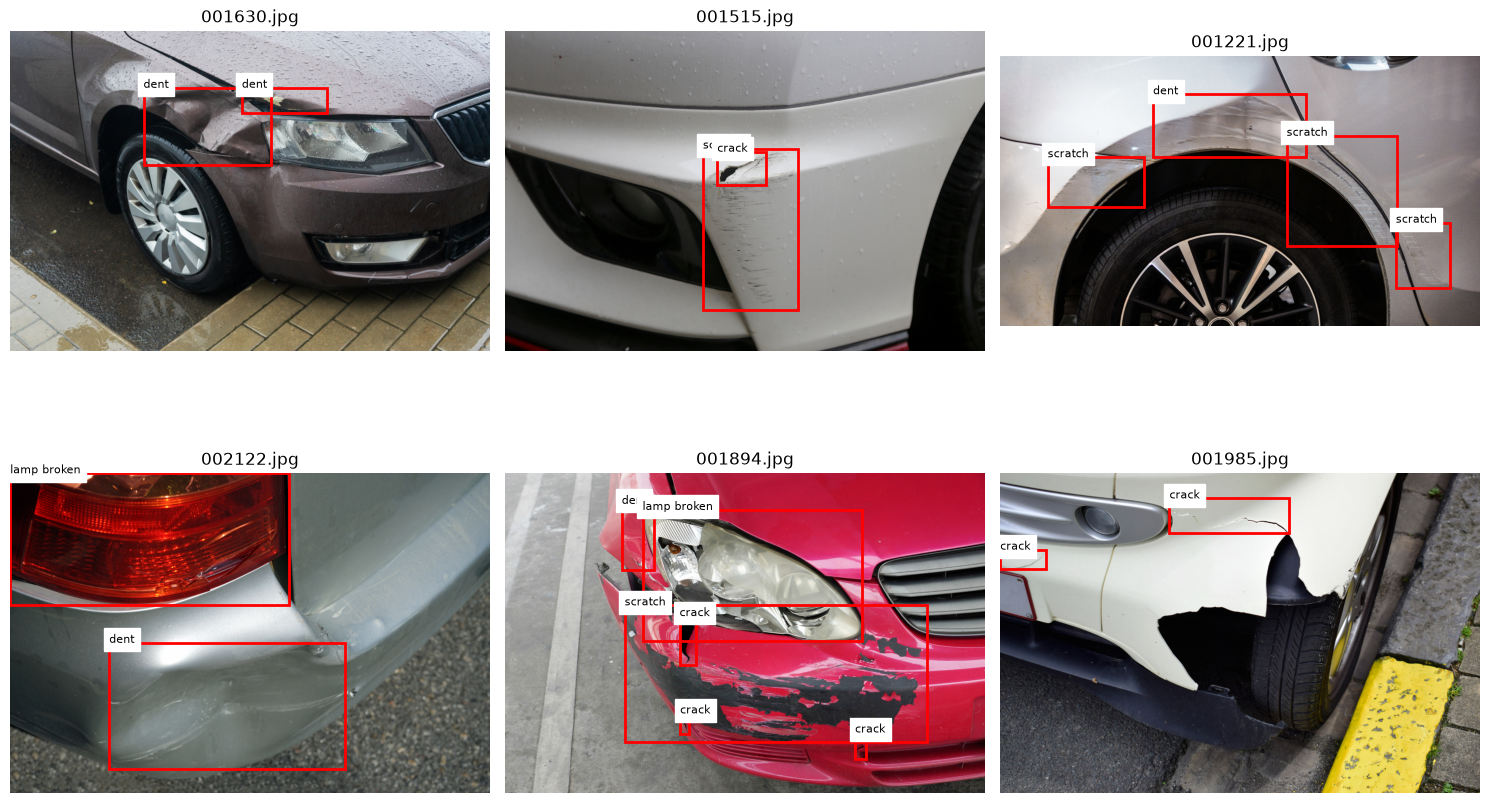

In [85]:
random_images = random.sample(train_images, 6)

plt.figure(figsize=(15, 10))

for i, image_path in enumerate(random_images):

    img = Image.open(image_path)

    image_name = image_path.name
    image_info = image_info_dict[image_name]
    image_id = image_info["id"]

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)

    if image_id in annotation_dict:

        for annotation in annotation_dict[image_id]:

            x, y, width, height = annotation["bbox"]

            category_id = annotation["category_id"]
            category_name = category_dict[category_id]

            rectangle = patches.Rectangle(
                (x, y),
                width,
                height,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )

            plt.gca().add_patch(rectangle)

            plt.text(
                x,
                y,
                category_name,
                fontsize=8,
                backgroundcolor="white"
            )

    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [86]:
import datasets

print(datasets.config.HF_DATASETS_CACHE)

C:\Users\Niraj Mhatre\.cache\huggingface\datasets
